In [ ]:
import torch
import matplotlib.pyplot as plt

In [3]:
# 对称阵
A=torch.tensor([[3.0,1.0,2.0],
                [1.0,1.0,1.5],
                [2.0,1.5,5.0]])

# test A_T==A
A_T=A.T
diff:torch.Tensor=A_T-A
print(f"diff:{diff}")
print(f'max diff:{diff.max()}')

diff:tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
max diff:0.0


In [12]:
# 特征分解， eigen_vectors：column 是特征向量
eigen_values, eigen_vectors=torch.linalg.eig(A)

# print eigen vectors and eigen values
print("=============================")
print(f'eigen_values:{eigen_values}')
print("=============================")
print(f'eigen_vectors:{eigen_vectors}')

# restore test
E = eigen_vectors.real # 基向量矩阵，[e1,e2,e3,...,en]
L = torch.diag(eigen_values.real) # 特征值对角阵矩阵
print(f'E:{E}\nL:{L}')

M1=A@E
M2=E@L
diff=M1-M2
print("=============================")
print(f'diff:{diff}, max:{diff.max()}')

# A 分解
A_=E@L@E.T
diff=A_-A
print("=============================")
print(f'diff:{diff}, max:{diff.max()}')


eigen_values:tensor([6.7962+0.j, 1.7665+0.j, 0.4373+0.j])
eigen_vectors:tensor([[ 0.5051+0.j,  0.8410+0.j,  0.1938+0.j],
        [ 0.2969+0.j,  0.0415+0.j, -0.9540+0.j],
        [ 0.8104+0.j, -0.5394+0.j,  0.2287+0.j]])
E:tensor([[ 0.5051,  0.8410,  0.1938],
        [ 0.2969,  0.0415, -0.9540],
        [ 0.8104, -0.5394,  0.2287]])
L:tensor([[6.7962, 0.0000, 0.0000],
        [0.0000, 1.7665, 0.0000],
        [0.0000, 0.0000, 0.4373]])
diff:tensor([[-1.1921e-06, -3.5763e-07, -5.9605e-08],
        [ 0.0000e+00, -3.7998e-07, -5.9605e-08],
        [-4.7684e-07, -5.9605e-07, -2.9802e-07]]), max:0.0
diff:tensor([[ 7.1526e-07,  2.3842e-07,  7.1526e-07],
        [ 2.3842e-07, -1.7881e-07, -1.1921e-07],
        [ 7.1526e-07, -1.1921e-07,  4.7684e-07]]), max:7.152557373046875e-07


eigen_values:tensor([3.+0.j, 2.+0.j]), eigen_vetctors:tensor([[ 1.0000+0.j, -0.7071+0.j],
        [ 0.0000+0.j,  0.7071+0.j]])


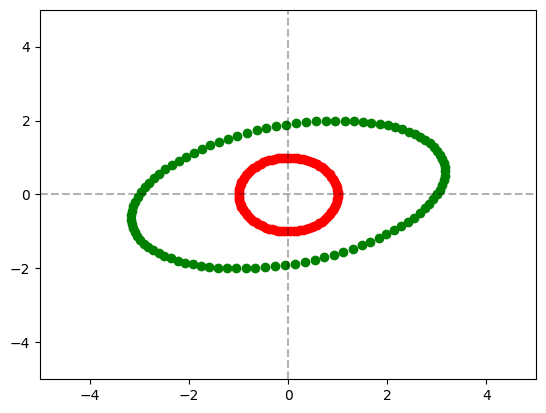

In [18]:
# practice 1
A=torch.tensor([[3.0,1.0],
                [0.0,2.0]])

# eigen value, eigen_vector
eigen_values, eigen_vetctors=torch.linalg.eig(A)
print(f'eigen_values:{eigen_values}, eigen_vetctors:{eigen_vetctors}')

# 标准圆形
N_POINTS=100
theta=torch.linspace(0,2*torch.pi,N_POINTS)
ux=torch.cos(theta)
uy=torch.sin(theta)
u_points=torch.column_stack([ux, uy])

# 变换
x_points=u_points@A.T

# plot
plt.scatter(u_points[:,0], u_points[:,1],c='r')
plt.scatter(x_points[:,0], x_points[:,1],c='g')
plt.xlim(-5,5)
plt.ylim(-5,5)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)